2024년 경주 발전량 예측모델

train 데이터 범위: 2020년 ~ 2022년 (3년)

valid 데이터 범위: 2023년 (1년)

test 데이터 범위: 2024년(1년, 실제 예측)

valid와 test의 날씨 데이터는 모두 하루전 예보된 데이터로, 정보누수가 없도록 했습니다.

예시: valid 데이터의 2023년 1월 2일 날씨 정보는 2023년 1월 1일 15시 이전에 발령된 기상 예보

In [1]:
import DataLoad, preprocess
#wtgs는 train의 날씨와 센서데이터를 merge 한뒤 딕셔너리화 한 것
wtgs, test, target = DataLoad.DataLoad()

wtg01 merged!
wtg02 merged!
wtg03 merged!
wtg04 merged!
wtg05 merged!
wtg06 merged!
wtg07 merged!
wtg08 merged!
wtg09 merged!
All DataLoad & Merge Complete!


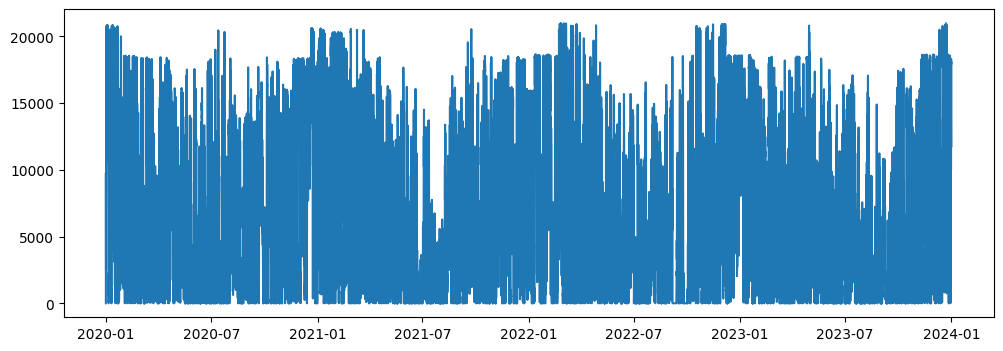

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(target.index, target)
plt.show()

In [3]:
import pandas as pd
target = pd.DataFrame({"energy_kwh":target}, index = target.index)

In [4]:
target["energy_kwh"] = target["energy_kwh"].astype("float32")

In [5]:

import torch
def make_baseline(df, window_size=7):
  df = df.copy()
  df = df.fillna(0)
  df_tmp = df.groupby(df.index.dayofyear).mean()
  df_extended = pd.concat([df_tmp.iloc[-window_size:], df_tmp, df_tmp.iloc[:window_size]])
  df_doy = df_extended.rolling(window=window_size, center=True).mean().iloc[window_size:-window_size]
  df_hour = df.groupby(df.index.hour).mean()
  import torch

  mean = df.mean()
  mean = torch.tensor(df.mean().values, dtype=torch.float)
  mean = mean

  doy_bias = torch.zeros(367)
  doy_bias = doy_bias.unsqueeze(1)
  doy_bias[1:] = torch.tensor(df_doy.values, dtype=torch.float) - mean
  hour_bias = torch.zeros(24)
  hour_bias = hour_bias.unsqueeze(1)
  hour_bias[:] = torch.tensor(df_hour.values, dtype=torch.float) - mean

  def baseline_estimator(doy, hour):
    return mean + doy_bias[doy] + hour_bias[hour]

  df['baseline'] = baseline_estimator(df.index.dayofyear, df.index.hour).numpy()
  return df

baseline = make_baseline(target, window_size= 31)


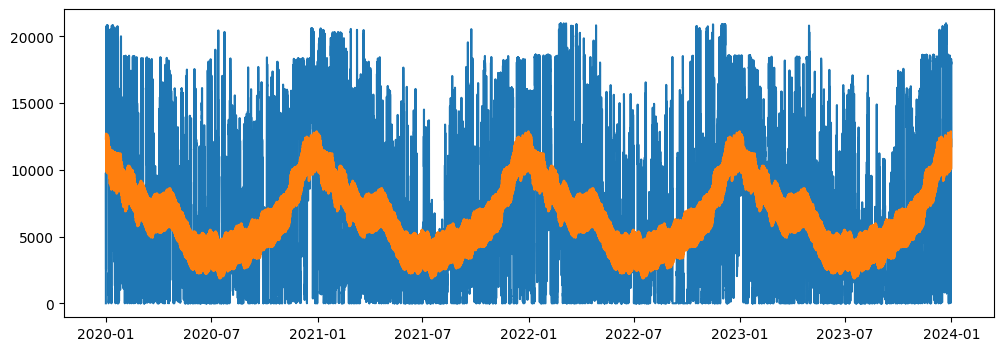

In [6]:
plt.figure(figsize = (12, 4))
plt.plot(baseline.index, baseline)
plt.show()

In [7]:
target

,energy_kwh
Date/Time,
2020-01-01 00:00:00,0.000000
2020-01-01 01:00:00,9767.578125
2020-01-01 02:00:00,5381.835938
2020-01-01 03:00:00,3021.484375
2020-01-01 04:00:00,4400.390625
...,...
2023-12-31 19:00:00,13666.015625
2023-12-31 20:00:00,11869.140625
2023-12-31 21:00:00,11761.718750


In [8]:
baseline

,energy_kwh,baseline
Date/Time,,
2020-01-01 00:00:00,0.000000,12330.995117
2020-01-01 01:00:00,9767.578125,12437.385742
2020-01-01 02:00:00,5381.835938,12490.744141
2020-01-01 03:00:00,3021.484375,12594.611328
2020-01-01 04:00:00,4400.390625,12680.056641
...,...,...
2023-12-31 19:00:00,13666.015625,10942.535156
2023-12-31 20:00:00,11869.140625,11440.447266
2023-12-31 21:00:00,11761.718750,11819.351562


In [9]:
target_roll = pd.DataFrame({"energy_kwh":baseline["baseline"]}, index = baseline.index)

In [10]:
target_roll

,energy_kwh
Date/Time,
2020-01-01 00:00:00,12330.995117
2020-01-01 01:00:00,12437.385742
2020-01-01 02:00:00,12490.744141
2020-01-01 03:00:00,12594.611328
2020-01-01 04:00:00,12680.056641
...,...
2023-12-31 19:00:00,10942.535156
2023-12-31 20:00:00,11440.447266
2023-12-31 21:00:00,11819.351562


In [11]:
bias = target - target_roll

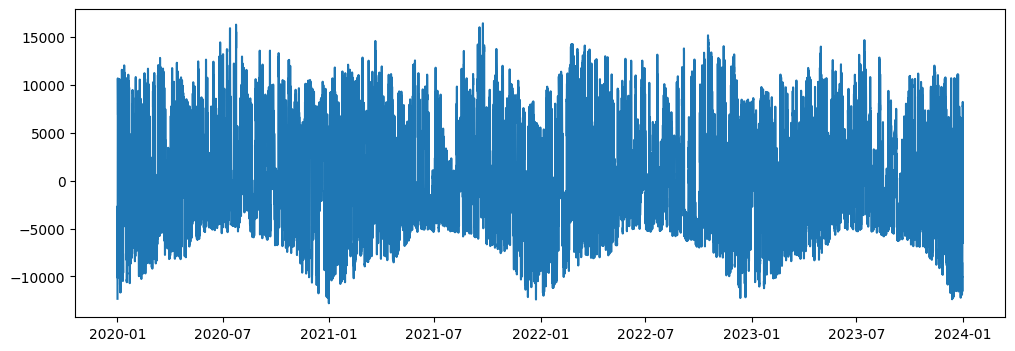

In [12]:
plt.figure(figsize=(12,4))
plt.plot(bias.index, bias)
plt.show()

In [13]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
# 전처리
wtgs_train, wtgs_valid, target_train, target_valid = preprocess.preprocessing(wtgs, bias)

In [15]:
wtg_names = [f"wtg0{i}"for i in range(1, 10)]
wtgs_train_2020 = {}
wtgs_train_2021 = {}
wtgs_train_2022 = {}

for wtg in wtg_names:
    wtgs_train_2020[wtg] = wtgs_train[wtg].loc["2020-01-01 00:00:00":"2020-12-31 23:00:00"]
    wtgs_train_2021[wtg] = wtgs_train[wtg].loc["2021-01-01 00:00:00":"2021-12-31 23:00:00"]
    wtgs_train_2022[wtg] = wtgs_train[wtg].loc["2022-01-01 00:00:00":"2022-12-31 23:00:00"]


target_train_2020 = target_train.loc["2020-01-01 00:00:00":"2020-12-31 23:00:00"]
target_train_2021 = target_train.loc["2021-01-01 00:00:00":"2021-12-31 23:00:00"]
target_train_2022 = target_train.loc["2022-01-01 00:00:00":"2022-12-31 23:00:00"]

In [16]:
# 센서 피쳐 예측용 데이터 스플릿
import feature_prediction
X_train_2020, y_train_2020, tests = feature_prediction.train_target_split(wtgs_train_2020, test)
X_train_2021, y_train_2021, tests = feature_prediction.train_target_split(wtgs_train_2021, test)
X_train_2022, y_train_2022, tests = feature_prediction.train_target_split(wtgs_train_2022, test)
X_valid, y_valid, _ = feature_prediction.train_target_split(wtgs_valid, test)

In [17]:
models = feature_prediction.models

In [18]:
tests["wtg01"].shape

(8784, 30)

In [19]:
import to_tensor
X_tensor_train_2020, X_tensor_valid, y_tensor_train_2020, y_tensor_valid, X_tensor_test = to_tensor.to_tensor(X_train_2020, X_valid, target_train_2020, target_valid, tests)
X_tensor_train_2021, X_tensor_valid, y_tensor_train_2021, y_tensor_valid, X_tensor_test = to_tensor.to_tensor(X_train_2021, X_valid, target_train_2021, target_valid, tests)
X_tensor_train_2022, X_tensor_valid, y_tensor_train_2022, y_tensor_valid, X_tensor_test = to_tensor.to_tensor(X_train_2022, X_valid, target_train_2022, target_valid, tests)

X_tensor_train_2020 = X_tensor_train_2020[:, 1, :, :].squeeze(1)
X_tensor_train_2021 = X_tensor_train_2021[:, 1, :, :].squeeze(1)
X_tensor_train_2022 = X_tensor_train_2022[:, 1, :, :].squeeze(1)

X_tensor_valid = X_tensor_valid[:, 1, :, :].squeeze(1)
X_tensor_test = X_tensor_test[:,1, :, :].squeeze(1)


X_train tensor shape: torch.Size([366, 9, 24, 30])
X_valid tensor shape: torch.Size([365, 9, 24, 30])
y_train tensor shape: torch.Size([366, 24, 1])
y_valid tensor shape: torch.Size([365, 24, 1])
test_tensor shape: torch.Size([366, 9, 24, 30])
X_train tensor shape: torch.Size([365, 9, 24, 30])
X_valid tensor shape: torch.Size([365, 9, 24, 30])
y_train tensor shape: torch.Size([365, 24, 1])
y_valid tensor shape: torch.Size([365, 24, 1])
test_tensor shape: torch.Size([366, 9, 24, 30])
X_train tensor shape: torch.Size([365, 9, 24, 30])
X_valid tensor shape: torch.Size([365, 9, 24, 30])
y_train tensor shape: torch.Size([365, 24, 1])
y_valid tensor shape: torch.Size([365, 24, 1])
test_tensor shape: torch.Size([366, 9, 24, 30])


In [20]:
X_tensor_train_2020 = X_tensor_train_2020.to(device)
X_tensor_train_2021 = X_tensor_train_2021.to(device)
X_tensor_train_2022 = X_tensor_train_2022.to(device)
X_tensor_valid = X_tensor_valid.to(device)
y_tensor_train_2020 = y_tensor_train_2020.to(device)
y_tensor_train_2021 = y_tensor_train_2021.to(device)
y_tensor_train_2022 = y_tensor_train_2022.to(device)
y_tensor_valid = y_tensor_valid.to(device)
X_tensor_test = X_tensor_test.to(device)

In [21]:
print(X_tensor_train_2020.shape)
print(X_tensor_valid.shape)
print(y_tensor_valid.shape)
print(y_tensor_train_2020.shape)
print(X_tensor_test.shape)

torch.Size([366, 24, 30])
torch.Size([365, 24, 30])
torch.Size([365, 24, 1])
torch.Size([366, 24, 1])
torch.Size([366, 24, 30])


In [22]:
import torch
import torch.nn as nn
import 경주model_test as 경주Model

X_tensor_list = [X_tensor_train_2020, X_tensor_train_2021, X_tensor_train_2022, X_tensor_valid]
y_tensor_list = [y_tensor_train_2020, y_tensor_train_2021, y_tensor_train_2022, y_tensor_valid]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def kfold_train(X_tensor_list, y_tensor_list, model_class, model_args, lr=0.0059, wd=0.0015, num_epochs=500):
    n_folds = len(X_tensor_list)
    fold_results = []
    fold_preds = [] 

    for fold in range(n_folds):
        print(f"\n========== Fold {fold+1}/{n_folds} ==========")

        # 1️⃣ Validation set
        X_valid = X_tensor_list[fold]
        y_valid = y_tensor_list[fold]

        # 2️⃣ 나머지 3년 → Train set
        X_train = torch.cat([X for i, X in enumerate(X_tensor_list) if i != fold], dim=0)
        y_train = torch.cat([y for i, y in enumerate(y_tensor_list) if i != fold], dim=0)

        # 3️⃣ 모델 초기화
        model = model_class(*model_args)
        model = model.to(device)

        # 4️⃣ 손실함수, 옵티마이저, 얼리스탑핑
        criterion = nn.L1Loss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
        early_stopping = 경주Model.EarlyStopping(patience=30, verbose=True, delta=0.0001)

        # 5️⃣ 학습 루프
        경주Model.train_loop(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            num_epochs=num_epochs,
            early_stopping=early_stopping,
            input_tensor=X_train,
            valid_tensor=X_valid,
            tg=y_train,
            vt=y_valid
        )

        # 6️⃣ Fold 결과 저장
        fold_results.append({
            "fold": fold+1,
            "valid_loss": early_stopping.best_score
        })

        model.eval()
        with torch.no_grad():
            predictions = model(X_tensor_test.to(device)).cpu().numpy()

        # 8️⃣ 역변환 후 DataFrame으로 저장
        output = predictions.reshape(-1, 1)
        output_inverse = to_tensor.target_scaler.inverse_transform(output)
        pred_df = pd.DataFrame(output_inverse, columns=[f"pred_fold{fold+1}"])

        fold_preds.append(pred_df)

    print("\n==== 모든 Fold 완료 ====")
    for res in fold_results:
        print(f"Fold {res['fold']} | Best Val Loss: {res['valid_loss']:.5f}")

    # 9️⃣ Fold 예측 평균
    pred_concat = pd.concat(fold_preds, axis=1)
    pred_concat["pred_mean"] = pred_concat.mean(axis=1)

    print("\n==== Fold별 예측 평균 완료 ====")
    return fold_results, pred_concat

In [23]:
results, pred = kfold_train(
    X_tensor_list=X_tensor_list,
    y_tensor_list=y_tensor_list,
    model_class=경주Model.FullModel,
    model_args=(X_tensor_train_2020,),  # FullModel 초기화용
    lr=0.0059,
    wd=0.0015,
    num_epochs=500
)


========== Fold 1/4 ==========
Epoch 0, Train Loss: 0.383449, Validation Loss: 0.1703
EarlyStopping counter: 1/30
Epoch 1, Train Loss: 0.175606, Validation Loss: 0.2861
Epoch 2, Train Loss: 0.271869, Validation Loss: 0.1631
EarlyStopping counter: 1/30
Epoch 3, Train Loss: 0.159977, Validation Loss: 0.1776
EarlyStopping counter: 2/30
Epoch 4, Train Loss: 0.185948, Validation Loss: 0.1713
Epoch 5, Train Loss: 0.177641, Validation Loss: 0.1609
EarlyStopping counter: 1/30
Epoch 6, Train Loss: 0.160506, Validation Loss: 0.1676
EarlyStopping counter: 2/30
Epoch 7, Train Loss: 0.162392, Validation Loss: 0.1769
EarlyStopping counter: 3/30
Epoch 8, Train Loss: 0.169569, Validation Loss: 0.1717
EarlyStopping counter: 4/30
Epoch 9, Train Loss: 0.165217, Validation Loss: 0.1632
Epoch 10, Train Loss: 0.159013, Validation Loss: 0.1598
Epoch 11, Train Loss: 0.157999, Validation Loss: 0.1597
EarlyStopping counter: 1/30
Epoch 12, Train Loss: 0.159951, Validation Loss: 0.1599
Epoch 13, Train Loss: 0.16

In [24]:
pred

,pred_fold1,pred_fold2,pred_fold3,pred_fold4,pred_mean
0,-5480.595703,-4291.893066,-4806.646484,-5505.240234,-5021.093750
1,-5707.641602,-4291.323730,-4870.905762,-5398.726562,-5067.149414
2,-5969.305664,-4291.408203,-5071.806152,-5490.845215,-5205.841309
3,-6250.521484,-4291.583008,-5446.011230,-5809.139648,-5449.313477
4,-6496.936523,-4291.736816,-5972.108887,-6241.314941,-5750.524414
...,...,...,...,...,...
8779,6997.992676,4176.865723,7533.547852,6779.232910,6371.909668
8780,6921.639648,4176.906738,7386.472656,6764.587402,6312.401855
8781,6859.392578,4176.950684,7276.985840,6762.592285,6268.980469
8782,6820.276855,4176.981934,7232.540527,6775.125488,6251.230957


In [25]:
import 경주model_test as 경주Model
import torch.nn as nn
"""
#모델의 위도와 경도를 기반으로 haversine 공식 기반으로 거리를 구한 뒤
#1KM 이내에 있는 터빈을 엣지로 연결할 수 있게 인접행렬을 만들었습니다. (Wake Effect가 1km 이내에서 자주 일어날 것이라고 가정)

#모델은 T축에 대해 Attention 입력(24시간에서의 중요도, Temporal Attention)
#N축에 대해 Attention Score을 구해 인접행렬에 곱해서 Weighted Adjacency matrix 생성 (Spatial Attention)
#이후 temporal attention 적용된 데이터와 Weighted Adjacency matrix으로 GCN 레이어 적용(GCN Layer)
#GCN 적용된 데이터를 lstm에 넣고, 출력층에서 N축에 대해 aggregation(mean) (lstmGCN)


model = 경주Model.FullModel(X_tensor_train_2020)
model = model.to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0059, weight_decay=0.0015) #모델의 loss가 한값에 고정되어 나오면 lr을 조금씩 수정해주세요
early_stopping = 경주Model.EarlyStopping(patience= 30, verbose= True, delta = 0.0001)


경주Model.train_loop(model= model,
                   criterion= criterion,
                   optimizer= optimizer,
                   num_epochs= 500,
                   early_stopping= early_stopping,
                   input_tensor= X_tensor_train_2020,
                   valid_tensor= X_tensor_valid,
                   tg = y_tensor_train_2020,
                   vt = y_tensor_valid)
"""

'\n#모델의 위도와 경도를 기반으로 haversine 공식 기반으로 거리를 구한 뒤\n#1KM 이내에 있는 터빈을 엣지로 연결할 수 있게 인접행렬을 만들었습니다. (Wake Effect가 1km 이내에서 자주 일어날 것이라고 가정)\n\n#모델은 T축에 대해 Attention 입력(24시간에서의 중요도, Temporal Attention)\n#N축에 대해 Attention Score을 구해 인접행렬에 곱해서 Weighted Adjacency matrix 생성 (Spatial Attention)\n#이후 temporal attention 적용된 데이터와 Weighted Adjacency matrix으로 GCN 레이어 적용(GCN Layer)\n#GCN 적용된 데이터를 lstm에 넣고, 출력층에서 N축에 대해 aggregation(mean) (lstmGCN)\n\n\nmodel = 경주Model.FullModel(X_tensor_train_2020)\nmodel = model.to(device)\ncriterion = nn.L1Loss()\noptimizer = torch.optim.AdamW(model.parameters(), lr=0.0059, weight_decay=0.0015) #모델의 loss가 한값에 고정되어 나오면 lr을 조금씩 수정해주세요\nearly_stopping = 경주Model.EarlyStopping(patience= 30, verbose= True, delta = 0.0001)\n\n\n경주Model.train_loop(model= model,\n                   criterion= criterion,\n                   optimizer= optimizer,\n                   num_epochs= 500,\n                   early_stopping= early_stopping,\n                   input_tensor= X_tensor_train_2

In [26]:
target_roll_2023 = target_roll.loc["2023-01-01 00:00:00":"2024-12-31 23:00:00"]

In [27]:
target_roll_2023

,energy_kwh
Date/Time,
2023-01-01 00:00:00,12330.995117
2023-01-01 01:00:00,12437.385742
2023-01-01 02:00:00,12490.744141
2023-01-01 03:00:00,12594.611328
2023-01-01 04:00:00,12680.056641
...,...
2023-12-31 19:00:00,10942.535156
2023-12-31 20:00:00,11440.447266
2023-12-31 21:00:00,11819.351562


In [28]:
target_roll_2023 = target_roll_2023.fillna(0)

In [29]:
target_roll_2023

,energy_kwh
Date/Time,
2023-01-01 00:00:00,12330.995117
2023-01-01 01:00:00,12437.385742
2023-01-01 02:00:00,12490.744141
2023-01-01 03:00:00,12594.611328
2023-01-01 04:00:00,12680.056641
...,...
2023-12-31 19:00:00,10942.535156
2023-12-31 20:00:00,11440.447266
2023-12-31 21:00:00,11819.351562


In [30]:
"""
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#Validation용 2023년 예측 및 시각화

model.eval()
with torch.no_grad():
    predictions  = model(X_tensor_valid)
    predictions_np = predictions.cpu().numpy() 

output = predictions_np
output = output.reshape(-1, 1)

output_inverse = to_tensor.target_scaler.inverse_transform(output)
output_inverse = output_inverse.reshape(-1, 1)

pred = pd.DataFrame(output_inverse, columns = ["pred"])
print(pred.shape)

target2023 = target_valid + target_roll_2023
pred.index = target_roll_2023.index

pred["pred"] = target_roll_2023["energy_kwh"] + pred["pred"]
pred["pred"] = np.clip(pred["pred"], a_min=0, a_max= 20700)
 
plt.figure(figsize = (12,4))
plt.plot(pred.index, pred, label = "pred")
plt.plot(target2023.index, target2023, label = "target", alpha = 0.4)
plt.legend()
plt.tight_layout()
plt.show()
"""

'\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport numpy as np\n\n#Validation용 2023년 예측 및 시각화\n\nmodel.eval()\nwith torch.no_grad():\n    predictions  = model(X_tensor_valid)\n    predictions_np = predictions.cpu().numpy() \n\noutput = predictions_np\noutput = output.reshape(-1, 1)\n\noutput_inverse = to_tensor.target_scaler.inverse_transform(output)\noutput_inverse = output_inverse.reshape(-1, 1)\n\npred = pd.DataFrame(output_inverse, columns = ["pred"])\nprint(pred.shape)\n\ntarget2023 = target_valid + target_roll_2023\npred.index = target_roll_2023.index\n\npred["pred"] = target_roll_2023["energy_kwh"] + pred["pred"]\npred["pred"] = np.clip(pred["pred"], a_min=0, a_max= 20700)\n \nplt.figure(figsize = (12,4))\nplt.plot(pred.index, pred, label = "pred")\nplt.plot(target2023.index, target2023, label = "target", alpha = 0.4)\nplt.legend()\nplt.tight_layout()\nplt.show()\n'

In [31]:
"""
#대회 전용 오차
#발전용량으로 정규화한 mae

#실제 센서데이터 사용시 NMAE 3~4 (사용 불가능. 2024년의 센서데이터가 없음)
#예측 센서데이터 사용시 NMAE 12~14(사용 가능)

def nmae(target, pred_target):
  mae = abs((target - pred_target))/20700
  nmae1 = mae.mean() * 100
  return nmae1

nmae1 = nmae(target2023["energy_kwh"], pred["pred"])
print(nmae1)
"""

'\n#대회 전용 오차\n#발전용량으로 정규화한 mae\n\n#실제 센서데이터 사용시 NMAE 3~4 (사용 불가능. 2024년의 센서데이터가 없음)\n#예측 센서데이터 사용시 NMAE 12~14(사용 가능)\n\ndef nmae(target, pred_target):\n  mae = abs((target - pred_target))/20700\n  nmae1 = mae.mean() * 100\n  return nmae1\n\nnmae1 = nmae(target2023["energy_kwh"], pred["pred"])\nprint(nmae1)\n'

In [32]:
target_roll_2024 = target_roll.loc["2020-01-01 01:00:00": "2021-01-01 00:00:00"]
target_roll_2024 = target_roll_2024.fillna(0)

target_roll_2024.index = test.index

In [33]:
target_roll_2024

,energy_kwh
2024-01-01 01:00:00,12437.385742
2024-01-01 02:00:00,12490.744141
2024-01-01 03:00:00,12594.611328
2024-01-01 04:00:00,12680.056641
2024-01-01 05:00:00,12714.859375
...,...
2024-12-31 20:00:00,11354.562500
2024-12-31 21:00:00,11733.466797
2024-12-31 22:00:00,11908.484375
2024-12-31 23:00:00,12183.928711


In [34]:
"""
import pandas as pd
import matplotlib.pyplot as plt

#실제 예측(2024년도)

model.eval()
with torch.no_grad():
    predictions  = model(X_tensor_test) 
    predictions_np = predictions.cpu().numpy()

output = predictions_np
output = output.reshape(-1, 1)

output_inverse = to_tensor.target_scaler.inverse_transform(output)
output_inverse = output_inverse.reshape(-1, 1)

pred = pd.DataFrame(output_inverse, columns = ["pred"])


pred.index = test.index
pred["pred"] = target_roll_2024["energy_kwh"] + pred["pred"]
pred["pred"] = np.clip(pred["pred"], a_min=0, a_max= 20700)


plt.figure(figsize = (12,4))
plt.plot(pred.index, pred, label = "pred")
plt.legend()
plt.tight_layout()
plt.show()
"""

'\nimport pandas as pd\nimport matplotlib.pyplot as plt\n\n#실제 예측(2024년도)\n\nmodel.eval()\nwith torch.no_grad():\n    predictions  = model(X_tensor_test) \n    predictions_np = predictions.cpu().numpy()\n\noutput = predictions_np\noutput = output.reshape(-1, 1)\n\noutput_inverse = to_tensor.target_scaler.inverse_transform(output)\noutput_inverse = output_inverse.reshape(-1, 1)\n\npred = pd.DataFrame(output_inverse, columns = ["pred"])\n\n\npred.index = test.index\npred["pred"] = target_roll_2024["energy_kwh"] + pred["pred"]\npred["pred"] = np.clip(pred["pred"], a_min=0, a_max= 20700)\n\n\nplt.figure(figsize = (12,4))\nplt.plot(pred.index, pred, label = "pred")\nplt.legend()\nplt.tight_layout()\nplt.show()\n'

In [35]:
target_roll

,energy_kwh
Date/Time,
2020-01-01 00:00:00,12330.995117
2020-01-01 01:00:00,12437.385742
2020-01-01 02:00:00,12490.744141
2020-01-01 03:00:00,12594.611328
2020-01-01 04:00:00,12680.056641
...,...
2023-12-31 19:00:00,10942.535156
2023-12-31 20:00:00,11440.447266
2023-12-31 21:00:00,11819.351562


In [36]:
df = target_roll.copy()
df['month'] = df.index.month
df['day'] = df.index.day
df['hour'] = df.index.hour  # 시간 단위라면

avg_target = df.groupby(['month','day','hour'])['energy_kwh'].mean().reset_index()
dates_2024 = pd.date_range('2024-01-01 01:00:00', '2025-01-01 00:00:00', freq='1h')
df_2024 = pd.DataFrame({'datetime': dates_2024})
df_2024['month'] = df_2024['datetime'].dt.month
df_2024['day'] = df_2024['datetime'].dt.day
df_2024['hour'] = df_2024['datetime'].dt.hour

df_2024 = df_2024.merge(avg_target, on=['month','day','hour'], how='left')
df_2024['target_roll'] = df_2024['energy_kwh'].interpolate()


In [37]:
df_2024

,datetime,month,day,hour,energy_kwh,target_roll
0,2024-01-01 01:00:00,1,1,1,12437.385742,12437.385742
1,2024-01-01 02:00:00,1,1,2,12490.744141,12490.744141
2,2024-01-01 03:00:00,1,1,3,12594.611328,12594.611328
3,2024-01-01 04:00:00,1,1,4,12680.056641,12680.056641
4,2024-01-01 05:00:00,1,1,5,12714.859375,12714.859375
...,...,...,...,...,...,...
8779,2024-12-31 20:00:00,12,31,20,11418.976562,11418.976562
8780,2024-12-31 21:00:00,12,31,21,11797.880859,11797.880859
8781,2024-12-31 22:00:00,12,31,22,11972.898438,11972.898438
8782,2024-12-31 23:00:00,12,31,23,12248.341797,12248.341797


In [38]:
df_2024.set_index("datetime", inplace= True)

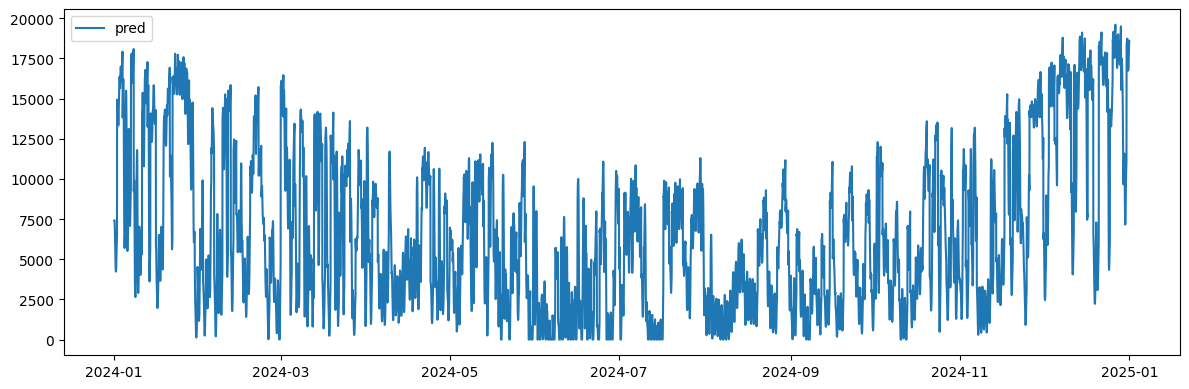

In [39]:
import numpy as np
pred.index = test.index
pred["pred"] = df_2024["target_roll"] + pred["pred_mean"]
pred["pred"] = np.clip(pred["pred"], a_min=0, a_max= 20700)


plt.figure(figsize = (12,4))
plt.plot(pred.index, pred["pred"], label = "pred")
plt.legend()
plt.tight_layout()
plt.show()

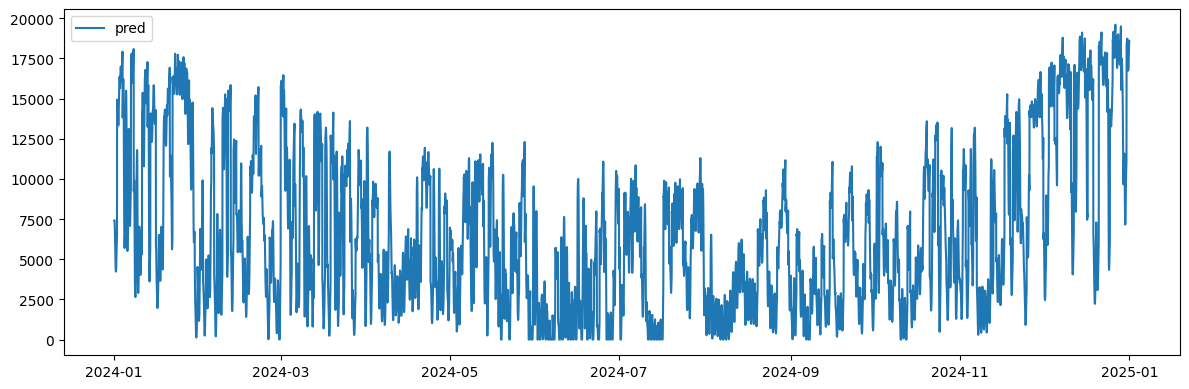

In [44]:
plt.figure(figsize = (12,4))
plt.plot(pred.index, pred["pred"], label = "pred")
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
pred = pred.drop(["pred_fold1", "pred_fold2", "pred_fold3", "pred_fold4", "pred_mean"], axis = 1)

In [41]:
pred.to_csv("경주_예측/경주.csv")